
## Normal



In [1]:
import pandas as pd
import numpy as np
import csv

UDP_FILE  = "udp_packets.csv"
RSSI_FILE = "sniffer_frames.csv"

udp = pd.read_csv(UDP_FILE)

# Robust RSSI load (skips broken rows if any)
rssi = pd.read_csv(
    RSSI_FILE,
    engine="python",
    on_bad_lines="skip",
    quoting=csv.QUOTE_MINIMAL
)

udp.head(), rssi.head()


(   run_id         scenario_id    ts_gateway node_id  boot_id  seq msg_type  \
 0     201  S1b_SYBIL_ONLY_ECG  1.770708e+09  ecg_01      244    0      ECG   
 1     201  S1b_SYBIL_ONLY_ECG  1.770708e+09  ecg_01      244    1      ECG   
 2     201  S1b_SYBIL_ONLY_ECG  1.770708e+09  ecg_01      244    2      ECG   
 3     201  S1b_SYBIL_ONLY_ECG  1.770708e+09  ecg_01      244    3      ECG   
 4     201  S1b_SYBIL_ONLY_ECG  1.770708e+09  ecg_01      244    4      ECG   
 
    payload_len       iat  seq_gap  seq_reset_flag  dup_seq_flag  \
 0           16 -1.000000       -1               0             0   
 1           16  0.469994        1               0             0   
 2           16  0.501390        1               0             0   
 3           16  0.499036        1               0             0   
 4           16  0.496269        1               0             0   
 
    out_of_order_flag  first_packet_flag  boot_change_flag  
 0                  0                  1             

In [2]:
# --- UDP cleaning ---
udp["ts_gateway"] = pd.to_numeric(udp["ts_gateway"], errors="coerce")
udp = udp.dropna(subset=["ts_gateway", "node_id"])

# Ensure numeric columns are numeric
num_cols_udp = [
    "boot_id","seq","payload_len","iat","seq_gap",
    "seq_reset_flag","dup_seq_flag","out_of_order_flag",
    "first_packet_flag","boot_change_flag"
]
for c in num_cols_udp:
    if c in udp.columns:
        udp[c] = pd.to_numeric(udp[c], errors="coerce")

# --- RSSI cleaning ---
rssi["ts_sniffer"] = pd.to_numeric(rssi["ts_sniffer"], errors="coerce")
rssi["rssi_dbm"]   = pd.to_numeric(rssi["rssi_dbm"], errors="coerce")
rssi["src_mac"]    = rssi["src_mac"].astype(str).str.lower()

rssi = rssi.dropna(subset=["ts_sniffer","src_mac","rssi_dbm"])

udp.shape, rssi.shape


((14289, 15), (382110, 3))

In [3]:
start_time = max(udp["ts_gateway"].min(), rssi["ts_sniffer"].min())

udp["t"]  = udp["ts_gateway"]  - start_time
rssi["t"] = rssi["ts_sniffer"] - start_time

end_time = min(udp["t"].max(), rssi["t"].max())

start_time, end_time


(np.float64(1770707806.955877), np.float64(7166.030333042145))

In [4]:
udp["node_id"].value_counts().head(15)

node_id
ecg_01    14289
Name: count, dtype: int64

In [12]:
rssi["src_mac"].value_counts().head(15)


src_mac
98:a9:42:17:7e:dc    311599
48:e7:da:aa:5e:95    122670
08:d1:f9:e8:84:c0     89144
84:1f:e8:36:62:98     51550
d8:d8:66:4e:79:d4     30779
98:a9:42:97:ae:03     16723
74:22:bb:03:88:97     11108
d8:d8:66:35:f2:66      9873
d8:d8:66:4f:d3:ea      9594
d8:d8:66:4d:b9:1c      9543
1c:b7:96:a3:78:a1      9338
d8:d8:66:35:81:c7      4795
36:3a:b3:2d:de:f9      3919
70:b5:e8:c6:b6:c1      3756
18:d9:8f:2d:46:64      3481
Name: count, dtype: int64

In [13]:
# TODO: replace with your real mapping
node_to_mac = {
    "ecg_01": "84:1f:e8:36:62:98",
    "eeg_01": "08:d1:f9:e8:84:c0",
}
node_to_mac = {k: v.lower() for k,v in node_to_mac.items()}


In [14]:
WINDOW = 5.0   # seconds
STRIDE = 1.0   # seconds
MIN_RSSI_FRAMES = 5  # below this, treat RSSI as missing

def safe_mean(x):
    return float(np.nanmean(x)) if len(x) else np.nan

def safe_std(x):
    return float(np.nanstd(x)) if len(x) else np.nan

def extract_window_features(udp, rssi, node_to_mac, window=5.0, stride=1.0):
    rows = []
    win_starts = np.arange(0, end_time - window + 1e-9, stride)

    # sort once for speed/stability
    udp = udp.sort_values("t")
    rssi = rssi.sort_values("t")

    for node_id, mac in node_to_mac.items():
        mac = mac.lower()

        udp_node = udp[udp["node_id"] == node_id]
        rssi_node = rssi[rssi["src_mac"] == mac]

        for ws in win_starts:
            we = ws + window

            u = udp_node[(udp_node["t"] >= ws) & (udp_node["t"] < we)]
            s = rssi_node[(rssi_node["t"] >= ws) & (rssi_node["t"] < we)]

            # --- UDP features ---
            pps = len(u) / window
            iat_vals = u["iat"].to_numpy() if "iat" in u.columns else np.array([])
            iat_vals = iat_vals[iat_vals >= 0]  # ignore -1 placeholders

            seq_gap_vals = u["seq_gap"].to_numpy() if "seq_gap" in u.columns else np.array([])
            seq_gap_vals = seq_gap_vals[seq_gap_vals >= 0]

            def rate(col):
                if col not in u.columns or len(u) == 0:
                    return np.nan
                return float(np.nanmean(u[col].to_numpy()))

            # --- RSSI features ---
            rssi_vals = s["rssi_dbm"].to_numpy()
            rssi_count = len(rssi_vals)

            rssi_missing = 1 if rssi_count < MIN_RSSI_FRAMES else 0

            rows.append({
                "node_id": node_id,
                "node_mac": mac,
                "window_start_s": float(ws),
                "window_end_s": float(we),

                # UDP
                "pps": float(pps),
                "iat_mean": safe_mean(iat_vals),
                "iat_std": safe_std(iat_vals),
                "seq_gap_mean": safe_mean(seq_gap_vals),
                "seq_gap_max": float(np.nanmax(seq_gap_vals)) if len(seq_gap_vals) else np.nan,
                "seq_reset_rate": rate("seq_reset_flag"),
                "dup_seq_rate": rate("dup_seq_flag"),
                "out_of_order_rate": rate("out_of_order_flag"),
                "boot_change_rate": rate("boot_change_flag"),
                "udp_pkt_count": int(len(u)),

                # RSSI
                "rssi_mean": safe_mean(rssi_vals),
                "rssi_std": safe_std(rssi_vals),
                "rssi_min": float(np.nanmin(rssi_vals)) if len(rssi_vals) else np.nan,
                "rssi_max": float(np.nanmax(rssi_vals)) if len(rssi_vals) else np.nan,
                "rssi_frame_count": int(rssi_count),
                "rssi_missing": int(rssi_missing),
            })

    return pd.DataFrame(rows)

features = extract_window_features(udp, rssi, node_to_mac, window=WINDOW, stride=STRIDE)
features.head(), features.shape


(  node_id           node_mac  window_start_s  window_end_s   pps  iat_mean  \
 0  ecg_01  84:1f:e8:36:62:98             0.0           5.0   4.0  0.097858   
 1  ecg_01  84:1f:e8:36:62:98             1.0           6.0   6.2  0.098747   
 2  ecg_01  84:1f:e8:36:62:98             2.0           7.0   8.2  0.098850   
 3  ecg_01  84:1f:e8:36:62:98             3.0           8.0  10.0  0.099288   
 4  ecg_01  84:1f:e8:36:62:98             4.0           9.0   9.6  0.103872   
 
     iat_std  seq_gap_mean  seq_gap_max  seq_reset_rate  dup_seq_rate  \
 0  0.048302           1.0          1.0             0.0           0.0   
 1  0.040644           1.0          1.0             0.0           0.0   
 2  0.037408           1.0          1.0             0.0           0.0   
 3  0.034212           1.0          1.0             0.0           0.0   
 4  0.039603           1.0          1.0             0.0           0.0   
 
    out_of_order_rate  boot_change_rate  udp_pkt_count  rssi_mean   rssi_std  \
 0  

In [15]:
# Fill missing RSSI values when RSSI is missing
features["rssi_mean"] = features["rssi_mean"].fillna(-100)
features["rssi_std"]  = features["rssi_std"].fillna(0)
features["rssi_min"]  = features["rssi_min"].fillna(-100)
features["rssi_max"]  = features["rssi_max"].fillna(-100)

# Fill missing UDP stats too (rare)
features["iat_mean"] = features["iat_mean"].fillna(-1)
features["iat_std"]  = features["iat_std"].fillna(-1)
features["seq_gap_mean"] = features["seq_gap_mean"].fillna(-1)
features["seq_gap_max"]  = features["seq_gap_max"].fillna(-1)

features.isna().sum().sort_values(ascending=False).head(10)


boot_change_rate     4616
seq_reset_rate       4616
out_of_order_rate    4616
dup_seq_rate         4616
window_end_s            0
window_start_s          0
node_mac                0
node_id                 0
seq_gap_mean            0
iat_std                 0
dtype: int64

In [16]:
OUT_FILE = "phaseA_window_features1.csv"
features.to_csv(OUT_FILE, index=False)


In [17]:
features["rssi_missing"].value_counts(normalize=True)


rssi_missing
1    0.644938
0    0.355062
Name: proportion, dtype: float64

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

FILE = "phaseA_window_features1.csv"   # change if your file name differs
df = pd.read_csv(FILE)

df.head(), df.shape


(  node_id           node_mac  window_start_s  window_end_s   pps  iat_mean  \
 0  ecg_01  84:1f:e8:36:62:98             0.0           5.0   4.0  0.097858   
 1  ecg_01  84:1f:e8:36:62:98             1.0           6.0   6.2  0.098747   
 2  ecg_01  84:1f:e8:36:62:98             2.0           7.0   8.2  0.098850   
 3  ecg_01  84:1f:e8:36:62:98             3.0           8.0  10.0  0.099288   
 4  ecg_01  84:1f:e8:36:62:98             4.0           9.0   9.6  0.103872   
 
     iat_std  seq_gap_mean  seq_gap_max  seq_reset_rate  dup_seq_rate  \
 0  0.048302           1.0          1.0             0.0           0.0   
 1  0.040644           1.0          1.0             0.0           0.0   
 2  0.037408           1.0          1.0             0.0           0.0   
 3  0.034212           1.0          1.0             0.0           0.0   
 4  0.039603           1.0          1.0             0.0           0.0   
 
    out_of_order_rate  boot_change_rate  udp_pkt_count  rssi_mean   rssi_std  \
 0  

In [19]:
# Columns you usually do NOT want as features
exclude = {"node_id","node_mac","window_start_s","window_end_s"}

num_cols = [c for c in df.columns if c not in exclude and pd.api.types.is_numeric_dtype(df[c])]

num_cols


['pps',
 'iat_mean',
 'iat_std',
 'seq_gap_mean',
 'seq_gap_max',
 'seq_reset_rate',
 'dup_seq_rate',
 'out_of_order_rate',
 'boot_change_rate',
 'udp_pkt_count',
 'rssi_mean',
 'rssi_std',
 'rssi_min',
 'rssi_max',
 'rssi_frame_count',
 'rssi_missing']

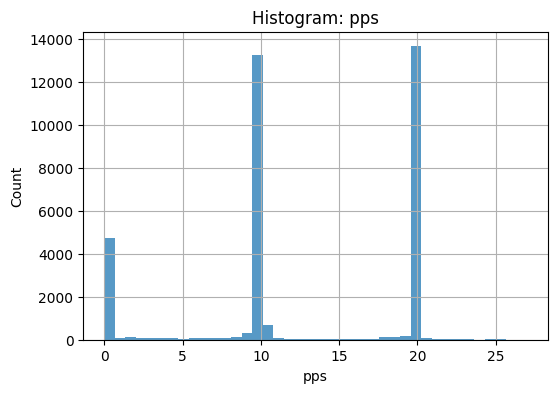

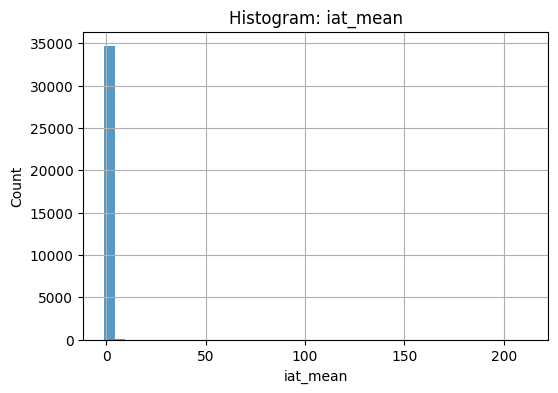

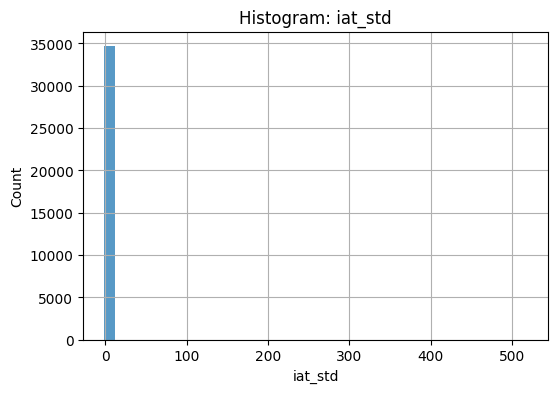

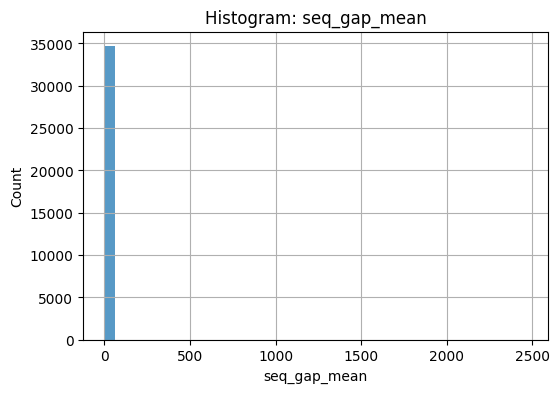

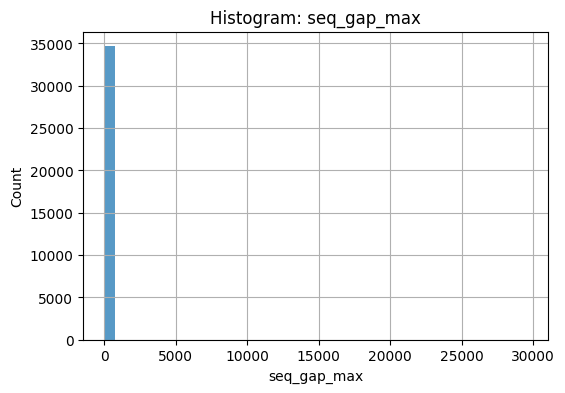

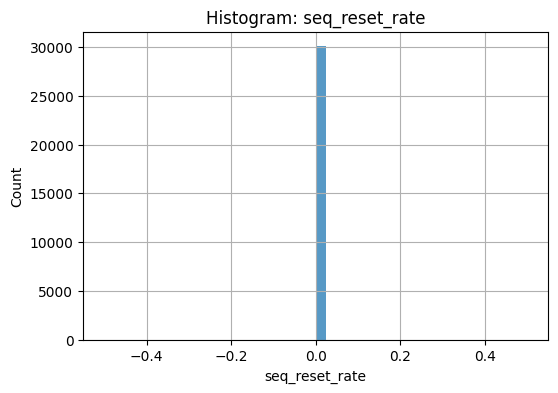

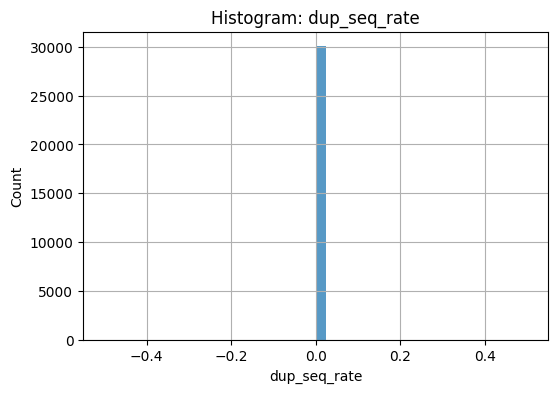

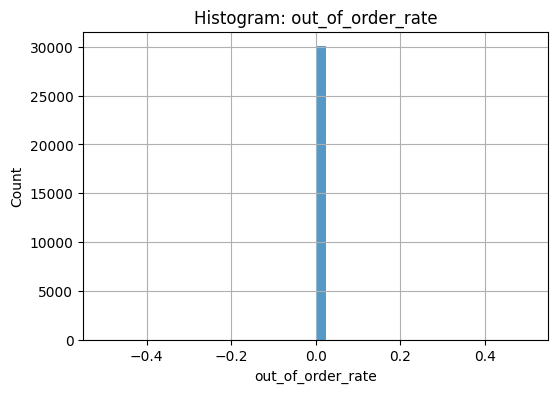

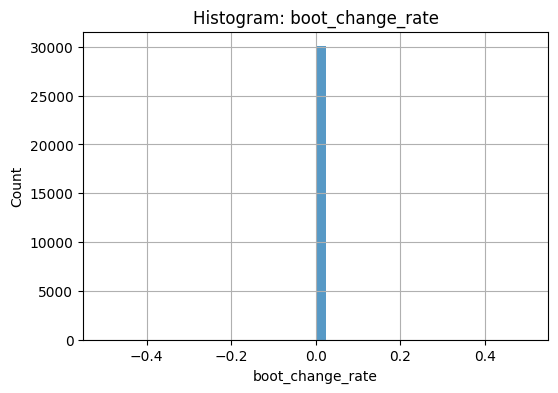

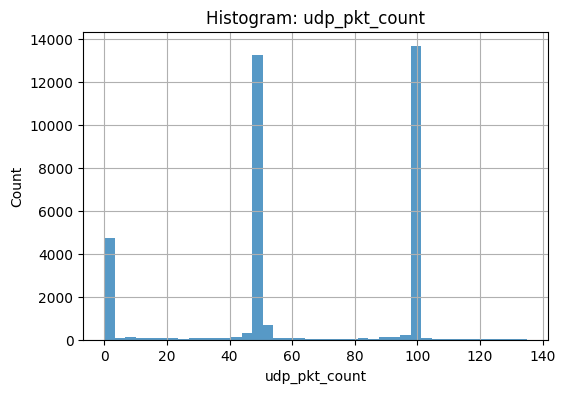

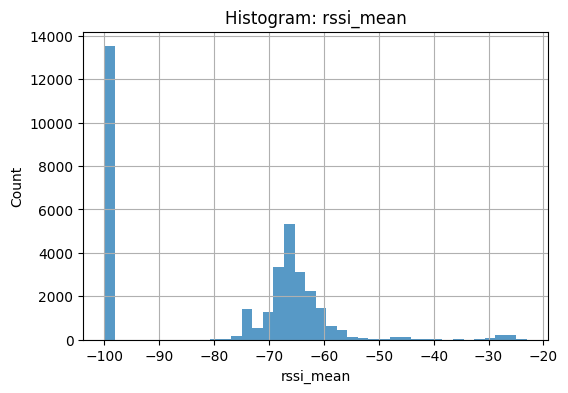

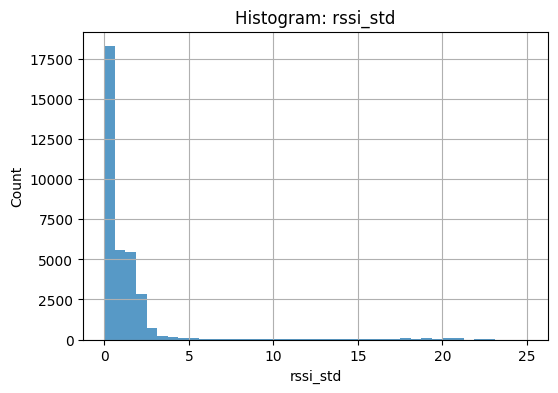

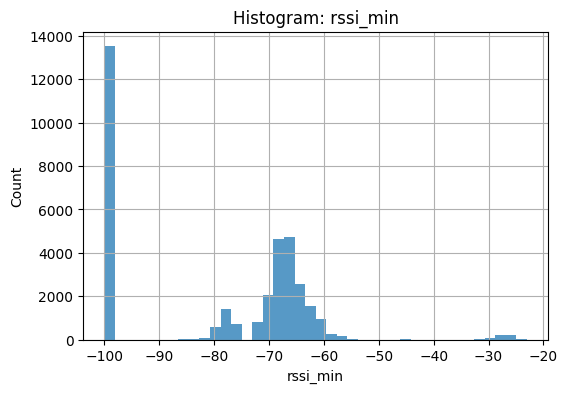

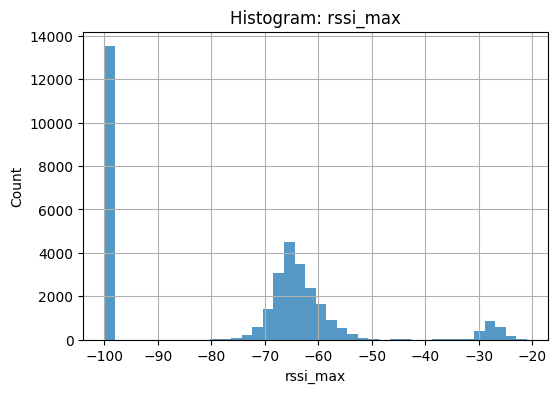

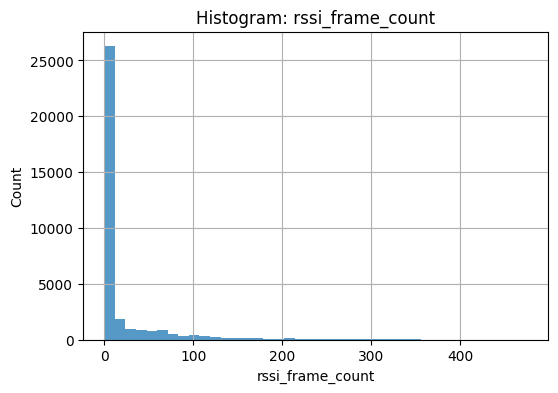

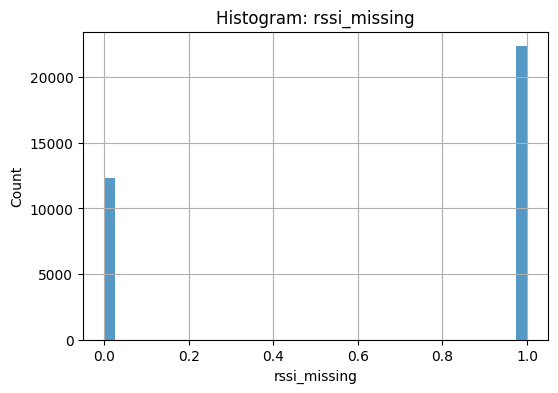

In [20]:
for col in num_cols:
    x = df[col].dropna()

    plt.figure(figsize=(6,4))
    plt.hist(x, bins=40, alpha=0.75)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()


### normal label

In [21]:
df["label"] = 0

In [22]:
df["label"].value_counts()


label
0    34670
Name: count, dtype: int64

In [24]:
df.to_csv("window_features_normal_labeled.csv", index=False)

In [ ]:
normal = pd.read_csv("window_features_normal_labeled.csv")
sybil  = pd.read_csv("window_features_sybil_sybil_labeled.csv")

full = pd.concat([normal, sybil], ignore_index=True)
full.to_csv("dataset_all_labeled.csv", index=False)


In [ ]:
files.download("dataset_all_labeled.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## sybil+ normal


In [2]:
import pandas as pd
import numpy as np
import csv

In [4]:
s1 = pd.read_csv("dataset_all_labeled1.csv")
s2 = pd.read_csv("dataset_all_labeled2.csv")
s3 = pd.read_csv("dataset_all_labeled3.csv")
s4 = pd.read_csv("dataset_all_labeled4.csv")

full = pd.concat([s1, s2, s3, s4], ignore_index=True)
full.to_csv("dataset_all_labeled.csv", index=False)

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

FILE = "dataset_all_labeled.csv"   # change to your file name
df = pd.read_csv(FILE)

df["label"].value_counts()


label
0    141244
1     25893
Name: count, dtype: int64

Select numeric feature columns

In [6]:
exclude = {
    "node_id","node_mac",
    "window_start_s","window_end_s"
}

X = df.drop(columns=list(exclude) + ["label"])
y = df["label"]


In [7]:
X = X.fillna(X.median(numeric_only=True))


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

logreg.fit(X_train, y_train)
pred = logreg.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.99      0.94     28249
           1       0.92      0.39      0.55      5179

    accuracy                           0.90     33428
   macro avg       0.91      0.69      0.75     33428
weighted avg       0.90      0.90      0.88     33428



In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)
pred = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, pred))


Random Forest
              precision    recall  f1-score   support

           0       0.99      0.86      0.92     28249
           1       0.56      0.97      0.71      5179

    accuracy                           0.88     33428
   macro avg       0.78      0.92      0.82     33428
weighted avg       0.93      0.88      0.89     33428



In [11]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)
pred = gb.predict(X_test)

print("Gradient Boosting")
print(classification_report(y_test, pred))


Gradient Boosting
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     28249
           1       0.99      0.70      0.82      5179

    accuracy                           0.95     33428
   macro avg       0.97      0.85      0.90     33428
weighted avg       0.95      0.95      0.95     33428



In [12]:
from sklearn.neural_network import MLPClassifier

mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(64,32),
        activation="relu",
        max_iter=500,
        early_stopping=True,
        random_state=42
    ))
])

mlp.fit(X_train, y_train)
pred = mlp.predict(X_test)

print("Neural Network (MLP)")
print(classification_report(y_test, pred))


Neural Network (MLP)
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     28249
           1       0.99      0.70      0.82      5179

    accuracy                           0.95     33428
   macro avg       0.97      0.85      0.90     33428
weighted avg       0.95      0.95      0.95     33428



In [13]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

models = {
    "LogReg": logreg,
    "RF": rf,
    "GB": gb,
    "MLP": mlp
}

results = []

for name, model in models.items():
    p = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1] if hasattr(model,"predict_proba") else None

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test,p),
        "f1": f1_score(y_test,p),
        "roc_auc": roc_auc_score(y_test, prob) if prob is not None else None
    })

pd.DataFrame(results)


,model,accuracy,f1,roc_auc
0,LogReg,0.900293,0.548313,0.866206
1,RF,0.878754,0.712696,0.974688
2,GB,0.952525,0.820007,0.974992
3,MLP,0.952884,0.821570,0.974632


In [14]:
import pandas as pd

imp = pd.Series(rf.feature_importances_, index=X.columns)
imp.sort_values(ascending=False).head(15)


iat_mean             0.221116
rssi_mean            0.164509
udp_pkt_count        0.136199
pps                  0.120683
rssi_max             0.107726
rssi_min             0.068921
iat_std              0.063267
rssi_frame_count     0.050908
seq_gap_max          0.022427
seq_gap_mean         0.020910
rssi_std             0.017384
rssi_missing         0.005918
out_of_order_rate    0.000033
seq_reset_rate       0.000000
dup_seq_rate         0.000000
dtype: float64

In [16]:
pip install tensorflow


   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/332.0 MB 1.3 MB/s eta 0:04:08
   ---------------------------------------- 0.8/332.0 MB 1.2 MB/s eta 0:04:32
   ---------------------------------------- 1.0/332.0 MB 1.2 MB/s eta 0:04:44
   ---------------------------------------- 1.3/332.0 MB 1.2 MB/s eta 0:04:47
   ---------------------------------------- 1.6/332.0 MB 1.1 MB/s eta 0:04:58
   ---------------------------------------- 1.6/332.0 MB 1.1 MB/s eta 0:04:58
   ---------------------------------------- 1.8/332.0 MB 1.1 MB/s eta 0:04:59
   ---------------------------------------- 2.1/332.0 MB 1.1 MB/s eta 0:05:03
   ---------------------------------------- 2.4/332.0 MB 1.1 MB/s eta 0:04:51
   ---------------------------------------- 2.4/332.0 MB 1.1 MB/s eta 0:04:51
   ----


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X_train_s.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_s, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    verbose=1
)

model.evaluate(X_test_s, y_test)


Epoch 1/40


c:\Users\ASUS TUF\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1672/1672 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9318 - loss: 0.2020 - val_accuracy: 0.9425 - val_loss: 0.1635
Epoch 2/40
1672/1672 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9435 - loss: 0.1496 - val_accuracy: 0.9479 - val_loss: 0.1441
Epoch 3/40
1672/1672 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9475 - loss: 0.1361 - val_accuracy: 0.9502 - val_loss: 0.1275
Epoch 4/40
1672/1672 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9494 - loss: 0.1292 - val_accuracy: 0.9520 - val_loss: 0.1253
Epoch 5/40
1672/1672 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9502 - loss: 0.1263 - val_accuracy: 0.9521 - val_loss: 0.1244
Epoch 6/40
1672/1672 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9506 - loss: 0.1250 - val_accuracy: 0.9520 - val_loss: 0.1235
Epoch 7/40
1672/1672 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9511 - loss: 0.1229 - val_accuracy: 0.9536 - val_loss: 0.1177
Epoch 8/40
1672/1672 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9511 - loss: 0.1222 - val_accurac

[0.11697106808423996, 0.9527043104171753]

#### random forest

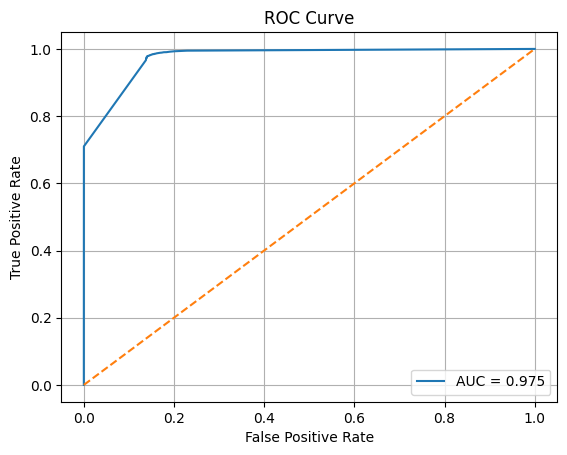

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Random Forest model
model = rf   # change to logreg, gb, mlp if needed

# Predict probabilities
y_prob = model.predict_proba(X_test)[:,1]

# ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


##### Confusion Matrix

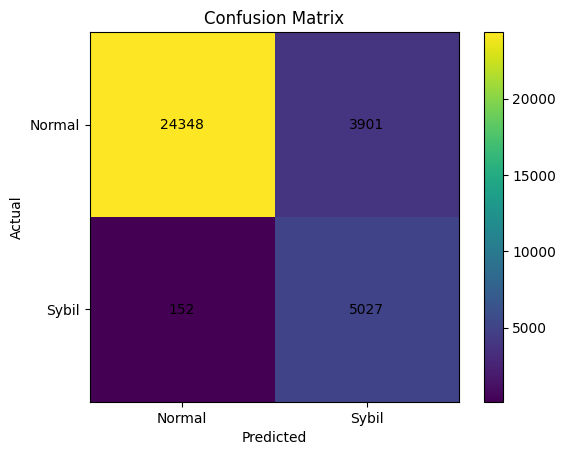

In [19]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, model.predict(X_test))

plt.figure()
plt.imshow(cm)
plt.colorbar()

plt.xticks([0,1],["Normal","Sybil"])
plt.yticks([0,1],["Normal","Sybil"])

for i in range(2):
    for j in range(2):
        plt.text(j,i,cm[i,j],ha="center",va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
### Feature Importance

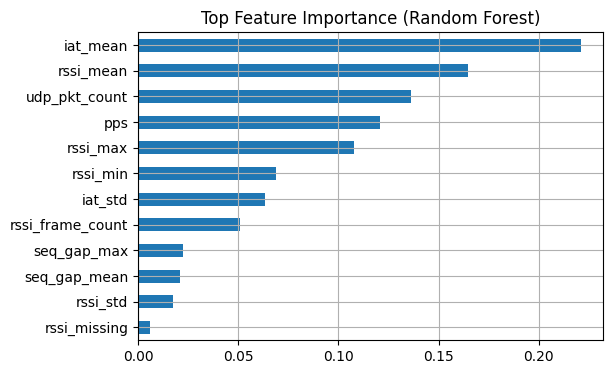

In [21]:
import pandas as pd

imp = pd.Series(rf.feature_importances_, index=X.columns)
imp = imp.sort_values(ascending=False).head(12)

plt.figure(figsize=(6,4))
imp.plot(kind="barh")
plt.title("Top Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()


##### Distribution Separation Plot

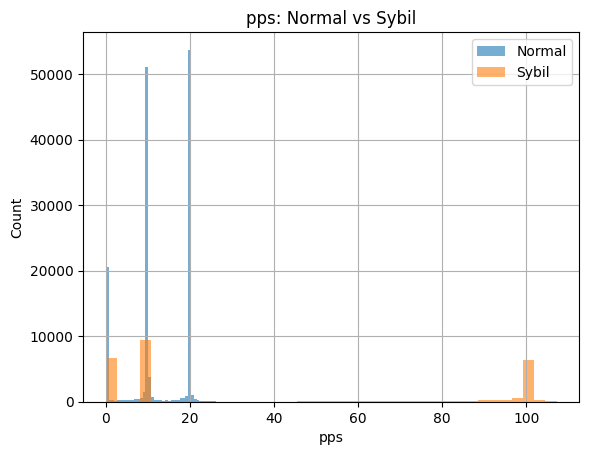

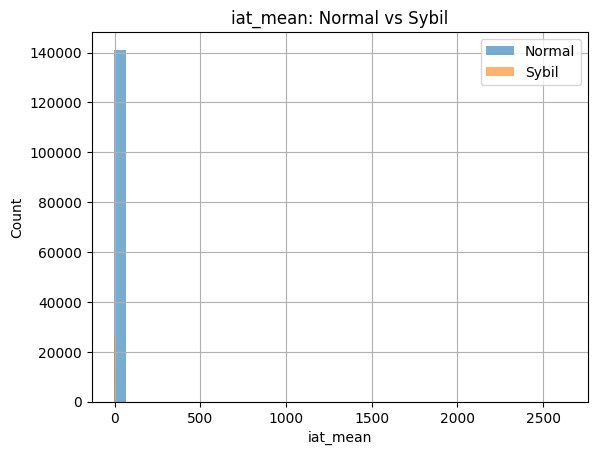

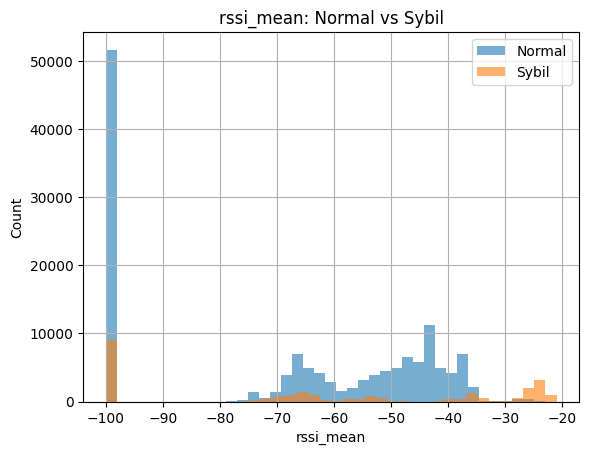

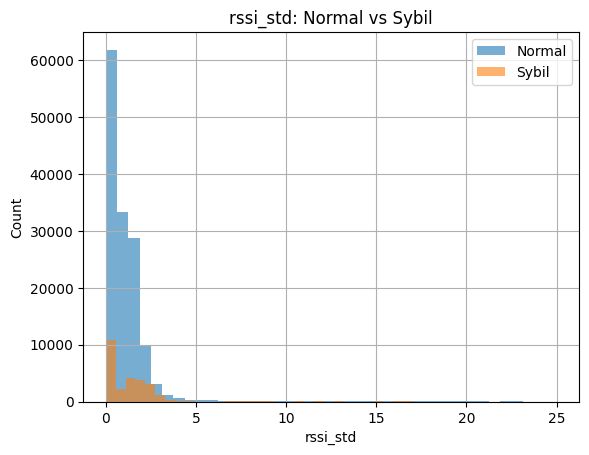

In [22]:
import matplotlib.pyplot as plt

features = ["pps","iat_mean","rssi_mean","rssi_std"]

for f in features:
    plt.figure()

    plt.hist(df[df["label"]==0][f], bins=40, alpha=0.6, label="Normal")
    plt.hist(df[df["label"]==1][f], bins=40, alpha=0.6, label="Sybil")

    plt.title(f"{f}: Normal vs Sybil")
    plt.xlabel(f)
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True)
    plt.show()


#### Train models

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

models = {
    "LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000))
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=42
    ),
    "GradBoost": GradientBoostingClassifier(random_state=42),
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(64,32),
            activation="relu",
            max_iter=500,
            early_stopping=True,
            random_state=42
        ))
    ])
}

for name, m in models.items():
    m.fit(X_train, y_train)
    print("trained:", name)


trained: LogReg
trained: RandomForest
trained: GradBoost
trained: MLP



MODEL: LogReg
              precision    recall  f1-score   support

           0     0.8989    0.9937    0.9440     28249
           1     0.9195    0.3906    0.5483      5179

    accuracy                         0.9003     33428
   macro avg     0.9092    0.6922    0.7461     33428
weighted avg     0.9021    0.9003    0.8827     33428



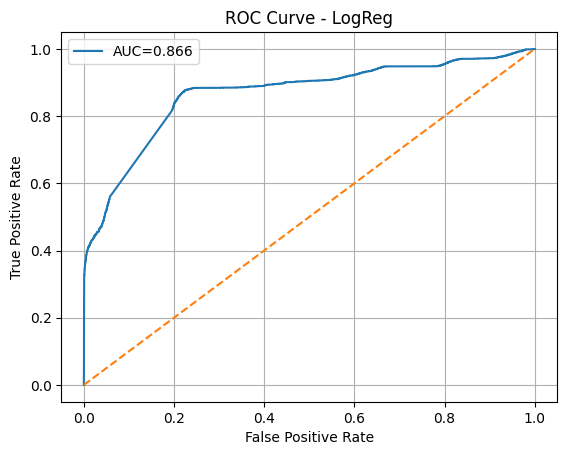

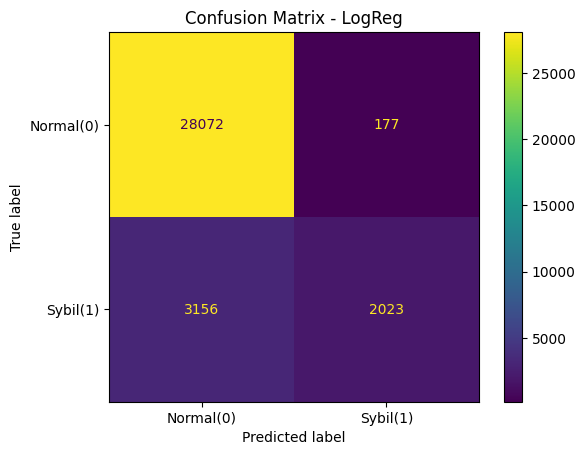


MODEL: RandomForest
              precision    recall  f1-score   support

           0     0.9938    0.8619    0.9232     28249
           1     0.5631    0.9707    0.7127      5179

    accuracy                         0.8788     33428
   macro avg     0.7784    0.9163    0.8179     33428
weighted avg     0.9271    0.8788    0.8906     33428



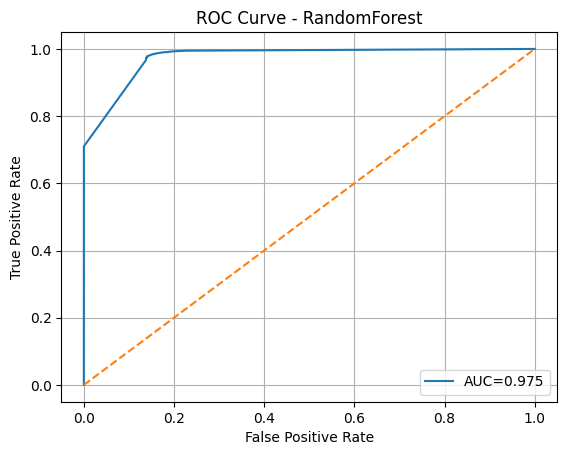

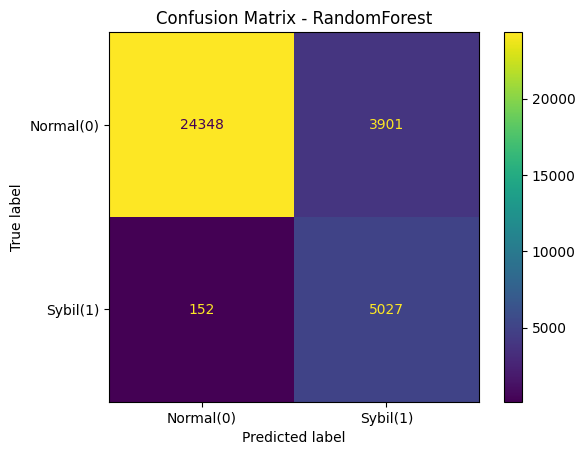


MODEL: GradBoost
              precision    recall  f1-score   support

           0     0.9475    0.9992    0.9727     28249
           1     0.9937    0.6980    0.8200      5179

    accuracy                         0.9525     33428
   macro avg     0.9706    0.8486    0.8963     33428
weighted avg     0.9547    0.9525    0.9490     33428



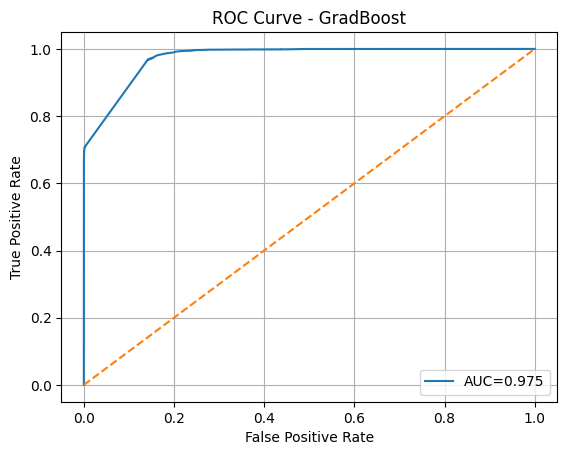

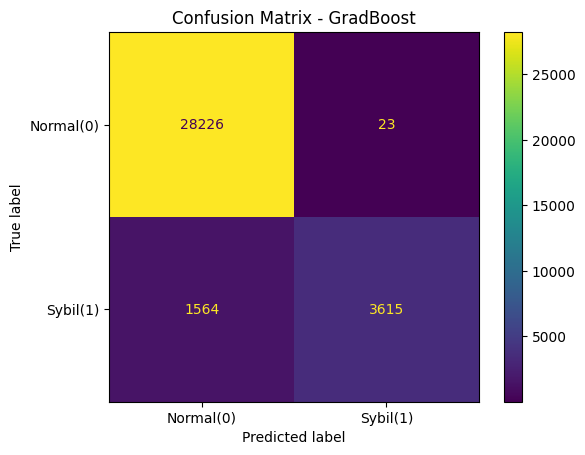


MODEL: MLP
              precision    recall  f1-score   support

           0     0.9479    0.9992    0.9729     28249
           1     0.9940    0.7001    0.8216      5179

    accuracy                         0.9529     33428
   macro avg     0.9709    0.8497    0.8972     33428
weighted avg     0.9550    0.9529    0.9494     33428



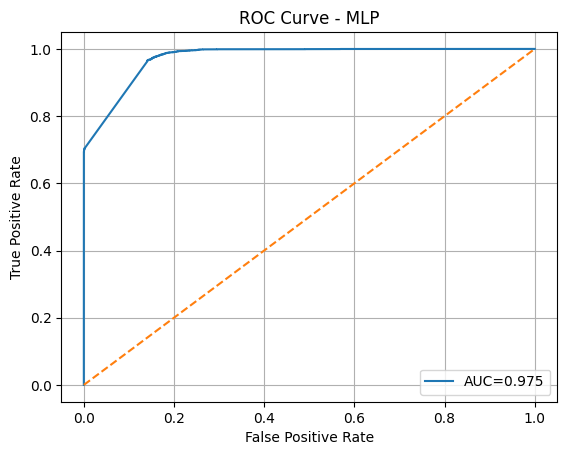

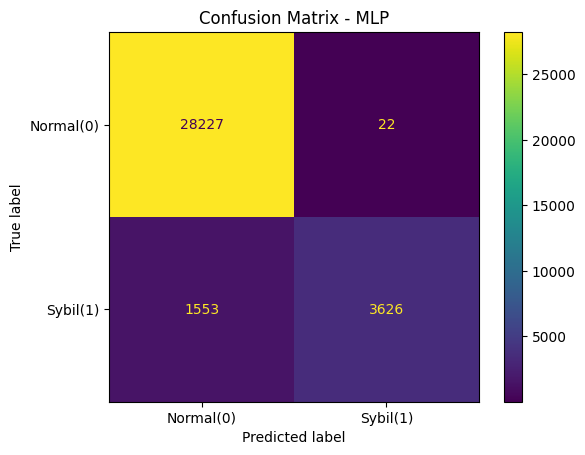

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, classification_report

def get_proba(model, X):
    # Works for pipelines and normal models
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:,1]
    # If a model doesn't support predict_proba, fallback to decision_function
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        # scale to 0-1 for ROC (not a true probability but OK for ROC curve)
        s = (s - s.min()) / (s.max() - s.min() + 1e-9)
        return s
    raise ValueError("Model has no predict_proba or decision_function")

for name, model in models.items():
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = get_proba(model, X_test)

    print("\n==============================")
    print("MODEL:", name)
    print(classification_report(y_test, y_pred, digits=4))

    # --- ROC Curve ---
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Normal(0)","Sybil(1)"])
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix - {name}")
    plt.grid(False)
    plt.show()



--- Feature importance for LogReg ---


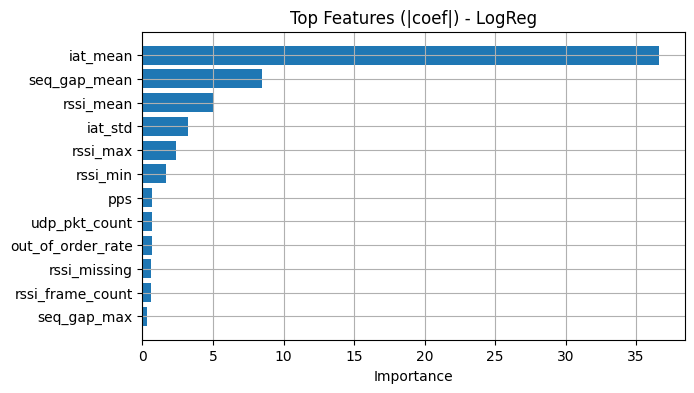


--- Feature importance for RandomForest ---


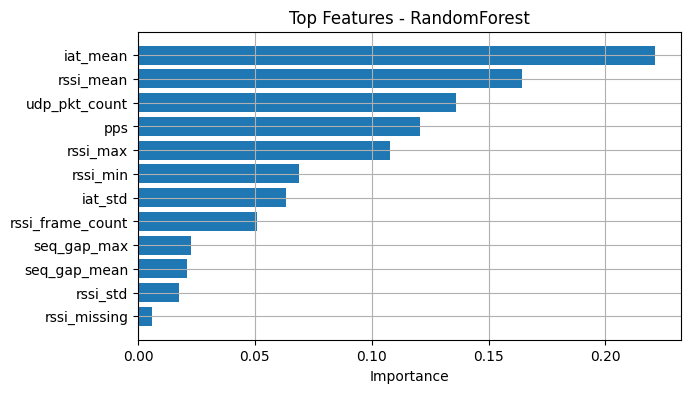


--- Feature importance for GradBoost ---


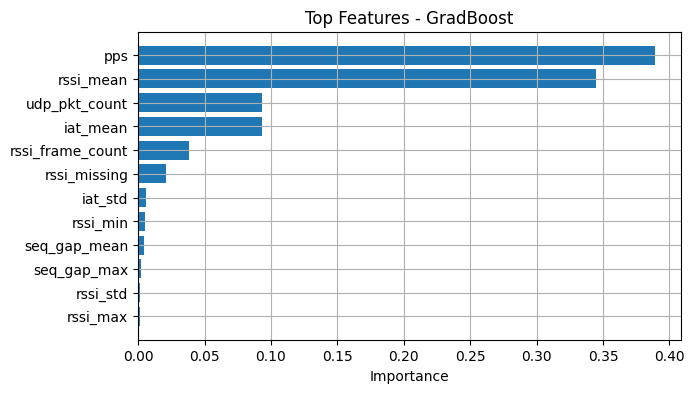


--- Feature importance for MLP ---


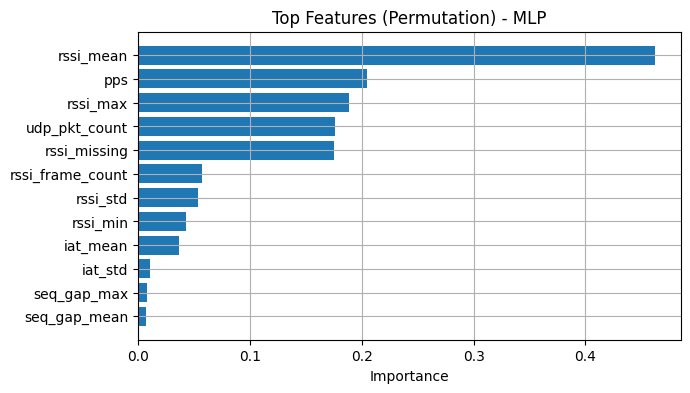

In [26]:
import pandas as pd
from sklearn.inspection import permutation_importance

feature_names = X_train.columns

def plot_top(series, title, topk=12):
    s = series.sort_values(ascending=False).head(topk)
    plt.figure(figsize=(7,4))
    plt.barh(s.index[::-1], s.values[::-1])
    plt.title(title)
    plt.xlabel("Importance")
    plt.grid(True)
    plt.show()

for name, model in models.items():
    print("\n--- Feature importance for", name, "---")

    if name in ["RandomForest", "GradBoost"]:
        imp = pd.Series(model.feature_importances_, index=feature_names)
        plot_top(imp, f"Top Features - {name}")

    elif name == "LogReg":
        # Get coefficients from pipeline
        clf = model.named_steps["clf"]
        coef = pd.Series(np.abs(clf.coef_[0]), index=feature_names)
        plot_top(coef, "Top Features (|coef|) - LogReg")

    elif name == "MLP":
        # Permutation importance (slow but reliable)
        r = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=42, scoring="f1")
        imp = pd.Series(r.importances_mean, index=feature_names)
        plot_top(imp, "Top Features (Permutation) - MLP")


In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, roc_auc_score

# Load labeled dataset
df = pd.read_csv("dataset_all_labeled.csv")

exclude = {"node_id","node_mac","window_start_s","window_end_s"}
X = df.drop(columns=list(exclude) + ["label"])
y = df["label"].astype(int).values

# Fill missing
X = X.fillna(X.median(numeric_only=True))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, stratify=y, random_state=42
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Class weights (handles imbalance)
classes = np.unique(y_train)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, cw)}
class_weight


{0: 0.5916589229611929, 1: 3.227503137974317}

In [2]:
from tensorflow.keras import layers, regularizers

tf.random.set_seed(42)

model = tf.keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),

    layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.3),

    layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.3),

    layers.Dense(32, kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", patience=8, mode="max", restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", patience=4, factor=0.5, mode="max", min_lr=1e-5)
]

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/100
418/418 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8115 - auc: 0.9106 - loss: 0.3849 - val_accuracy: 0.8531 - val_auc: 0.9522 - val_loss: 0.2576 - learning_rate: 0.0010
Epoch 2/100
418/418 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8505 - auc: 0.9453 - loss: 0.3014 - val_accuracy: 0.8593 - val_auc: 0.9623 - val_loss: 0.2260 - learning_rate: 0.0010
Epoch 3/100
418/418 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8561 - auc: 0.9541 - loss: 0.2728 - val_accuracy: 0.8598 - val_auc: 0.9677 - val_loss: 0.2251 - learning_rate: 0.0010
Epoch 4/100
418/418 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8607 - auc: 0.9598 - loss: 0.2560 - val_accuracy: 0.8631 - val_auc: 0.9704 - val_loss: 0.2274 - learning_rate: 0.0010
Epoch 5/100
418/418 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8626 - auc: 0.9617 - loss: 0.2478 - val_accuracy: 0.8673 - val_auc: 0.9706 - val_loss: 0.2146 - learning_rate: 0.0010
Epoch 6/100
418/418 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8640 - a

In [3]:
y_prob = model.predict(X_test).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


1045/1045 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score   support

           0     0.9900    0.8582    0.9194     28249
           1     0.5519    0.9529    0.6990      5179

    accuracy                         0.8728     33428
   macro avg     0.7710    0.9055    0.8092     33428
weighted avg     0.9222    0.8728    0.8852     33428

ROC-AUC: 0.9717249413541841


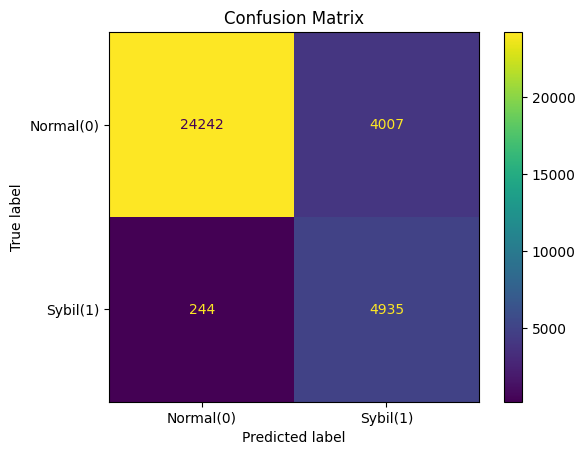

In [10]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, classification_report
# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal(0)","Sybil(1)"])
disp.plot(values_format="d")
plt.title(f"Confusion Matrix")
plt.grid(False)
plt.show()

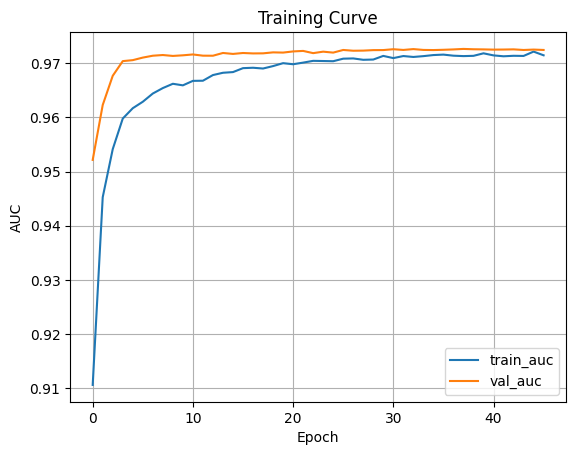

In [4]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["auc"], label="train_auc")
plt.plot(history.history["val_auc"], label="val_auc")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Training Curve")
plt.legend()
plt.grid(True)
plt.show()


In [11]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.linspace(0.1, 0.9, 50)

best_t = 0.5
best_f1 = 0

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Best F1:", best_f1)


Best threshold: 0.8183673469387756
Best F1: 0.8150754909751391


In [12]:
y_pred = (y_prob >= best_t).astype(int)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.95      1.00      0.97     28249
           1       0.99      0.69      0.82      5179

    accuracy                           0.95     33428
   macro avg       0.97      0.85      0.89     33428
weighted avg       0.95      0.95      0.95     33428



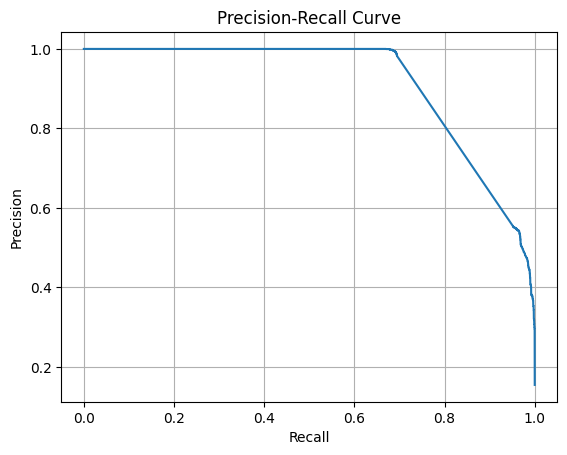

In [13]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()
